# NEXT Transformer — Final Results Dashboard

This notebook is **read-only**: it does not load the dataset, construct a model, or start training. It reads the completed EnergyBench outputs, verifies the four expected evaluations, ranks the models, and displays the saved evaluation figures.

Run all cells after the training notebook has finished. If the results live somewhere else, set the `NEXT_RESULTS_ROOT` environment variable or edit `RESULTS_ROOT` in the next cell.

In [ ]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

DEFAULT_RESULTS_ROOT = Path(
    "/home/klz/Data/zeronu_benchmark/Transformer_Approach/"
    "next_detector/results/final_cached_v1"
)
RESULTS_ROOT = Path(os.environ.get("NEXT_RESULTS_ROOT", DEFAULT_RESULTS_ROOT))
SUMMARY_PATH = RESULTS_ROOT / "transformer_results.csv"

EXPECTED_MODELS = [
    "transformer_001_sampled_hits_coordinate_mlp",
    "transformer_002_voxel_coordinate_mlp",
    "transformer_003_voxel_fourier_xyz",
    "transformer_004_sampled_hits_fourier_xyz",
]

DISPLAY_NAMES = {
    "transformer_001_sampled_hits_coordinate_mlp": "Sampled hits + Coordinate MLP",
    "transformer_002_voxel_coordinate_mlp": "Voxel + Coordinate MLP",
    "transformer_003_voxel_fourier_xyz": "Voxel + Fourier XYZ",
    "transformer_004_sampled_hits_fourier_xyz": "Sampled hits + Fourier XYZ",
}

print("Results directory:", RESULTS_ROOT)
print("Summary file:", SUMMARY_PATH)

Results directory: /home/klz/Data/zeronu_benchmark/Transformer_Approach/next_detector/results/final_cached_v1
Summary file: /home/klz/Data/zeronu_benchmark/Transformer_Approach/next_detector/results/final_cached_v1/transformer_results.csv


## 1. Completion and integrity checks

The CSV is the experiment-level summary. This cell also compares its values with each model's independent `evaluation/metrics.json` file and checks that the expected checkpoints and plots exist.

In [2]:
if not SUMMARY_PATH.is_file():
    raise FileNotFoundError(
        f"Final summary not found: {SUMMARY_PATH}\n"
        "Training may still be running, or RESULTS_ROOT needs to be changed."
    )

results = pd.read_csv(SUMMARY_PATH)
if "model_id" not in results.columns:
    raise ValueError("transformer_results.csv has no model_id column")
if results["model_id"].duplicated().any():
    duplicates = results.loc[results["model_id"].duplicated(), "model_id"].tolist()
    raise ValueError(f"Duplicate completed model rows: {duplicates}")

completed = set(results["model_id"].astype(str))
missing = [model_id for model_id in EXPECTED_MODELS if model_id not in completed]
unexpected = sorted(completed - set(EXPECTED_MODELS))

audit_rows = []
metric_map = {
    "inclusive_auc": "auc",
    "energy_matched_auc": "matched_auc",
    "common_support_auc": "common_support_auc",
    "shortcut_gap": "shortcut_gap",
    "energy_independence_score": "energy_independence_score",
    "worst_energy_independence_score": "worst_energy_independence_score",
}

for _, row in results.iterrows():
    model_id = str(row["model_id"])
    run_root = RESULTS_ROOT / model_id
    metrics_path = run_root / "evaluation" / "metrics.json"
    metrics_match = False
    if metrics_path.is_file():
        metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
        comparisons = []
        for csv_name, json_name in metric_map.items():
            csv_value = row.get(csv_name)
            json_value = metrics.get(json_name)
            if pd.isna(csv_value) and json_value is None:
                comparisons.append(True)
            elif json_value is None:
                comparisons.append(False)
            else:
                comparisons.append(np.isclose(float(csv_value), float(json_value), rtol=1e-9, atol=1e-12))
        metrics_match = all(comparisons)

    required_artifacts = [
        run_root / "training" / "best_model.pt",
        run_root / "training" / "last_model.pt",
        metrics_path,
        run_root / "evaluation" / "predictions.npz",
        run_root / "evaluation" / "energy_matched_roc.png",
        run_root / "evaluation" / "score_energy_dependence.png",
    ]
    audit_rows.append({
        "model": DISPLAY_NAMES.get(model_id, model_id),
        "CSV row": True,
        "metrics agree": metrics_match,
        "artifacts found": sum(path.is_file() for path in required_artifacts),
        "artifacts expected": len(required_artifacts),
        "complete": metrics_match and all(path.is_file() for path in required_artifacts),
    })

print(f"Completed evaluations: {len(results)}/{len(EXPECTED_MODELS)}")
if missing:
    print("WARNING — missing final evaluations:")
    for model_id in missing:
        print(" -", model_id)
else:
    print("All four expected models have final held-out-test results.")
if unexpected:
    print("Additional model rows:", unexpected)

audit = pd.DataFrame(audit_rows)
display(audit)

Completed evaluations: 4/4
All four expected models have final held-out-test results.


,model,CSV row,metrics agree,artifacts found,artifacts expected,complete
0,Sampled hits + Coordinate MLP,True,True,6,6,True
1,Voxel + Coordinate MLP,True,True,6,6,True
2,Voxel + Fourier XYZ,True,True,6,6,True
3,Sampled hits + Fourier XYZ,True,True,6,6,True


## 2. Ranked final results

Models are ranked by **energy-matched test AUC**, the primary classification benchmark. Validation AUC selected the checkpoint; it is not the final test result.

In [10]:
ranked = results.copy()
ranked["model"] = ranked["model_id"].map(DISPLAY_NAMES).fillna(ranked["model_id"])
ranked["training_hours"] = ranked["training_seconds"] / 3600
ranked["evaluation_minutes"] = ranked["evaluation_seconds"] / 60
ranked["validation_to_test_gap"] = ranked["best_validation_auc"] - ranked["energy_matched_auc"]
ranked = ranked.sort_values("energy_matched_auc", ascending=False).reset_index(drop=True)
ranked.insert(0, "rank", np.arange(1, len(ranked) + 1))

table_columns = [
    "rank", "model", "parameter_count", "best_epoch",
    "best_validation_auc", "energy_matched_auc","training_hours","energy_independence_score", "inclusive_auc",
    "common_support_auc", "shortcut_gap",
    "worst_energy_independence_score",
     "evaluation_minutes",
]
display(
    ranked[table_columns].style.format({
        "parameter_count": "{:,}",
        "best_validation_auc": "{:.6f}",
        "energy_matched_auc": "{:.6f}",
        "training_hours": "{:.2f}",
         "energy_independence_score": "{:.6f}",
        "inclusive_auc": "{:.6f}",
       
        "common_support_auc": "{:.6f}",
        "shortcut_gap": "{:.6f}",
        "energy_independence_score": "{:.6f}",
        "worst_energy_independence_score": "{:.6f}",
        
        "evaluation_minutes": "{:.2f}",
    }).background_gradient(subset=["energy_matched_auc"], cmap="Greens")
)

,rank,model,parameter_count,best_epoch,best_validation_auc,energy_matched_auc,training_hours,energy_independence_score,inclusive_auc,common_support_auc,shortcut_gap,worst_energy_independence_score,evaluation_minutes
0,1,Voxel + Coordinate MLP,"111,105",47,0.988214,0.987718,6.22,0.973246,0.987943,0.987933,0.000214,0.966642,0.38
1,2,Voxel + Fourier XYZ,"113,409",50,0.979266,0.978698,8.73,0.972763,0.978971,0.978933,0.000236,0.967611,0.90
2,3,Sampled hits + Coordinate MLP,"111,105",23,0.975839,0.975494,3.91,0.975270,0.975567,0.975581,0.000087,0.971484,0.53
3,4,Sampled hits + Fourier XYZ,"113,409",44,0.962205,0.962730,9.35,0.974274,0.962684,0.962672,-0.000058,0.973252,0.40


## 3. The 2 × 2 experiment matrix

In [4]:
matched_matrix = results.pivot(
    index="tokenization", columns="position_encoding", values="energy_matched_auc"
)
independence_matrix = results.pivot(
    index="tokenization", columns="position_encoding", values="energy_independence_score"
)

display(Markdown("### Energy-matched test AUC"))
display(matched_matrix.style.format("{:.6f}").background_gradient(cmap="Greens", axis=None))
display(Markdown("### Energy-independence score"))
display(independence_matrix.style.format("{:.6f}").background_gradient(cmap="Blues", axis=None))

### Energy-matched test AUC

position_encoding,coordinate_mlp,fourier_xyz
tokenization,,
sampled_hits,0.975494,0.962730
voxel,0.987718,0.978698


### Energy-independence score

position_encoding,coordinate_mlp,fourier_xyz
tokenization,,
sampled_hits,0.975270,0.974274
voxel,0.973246,0.972763


## 4. Metric and runtime comparisons

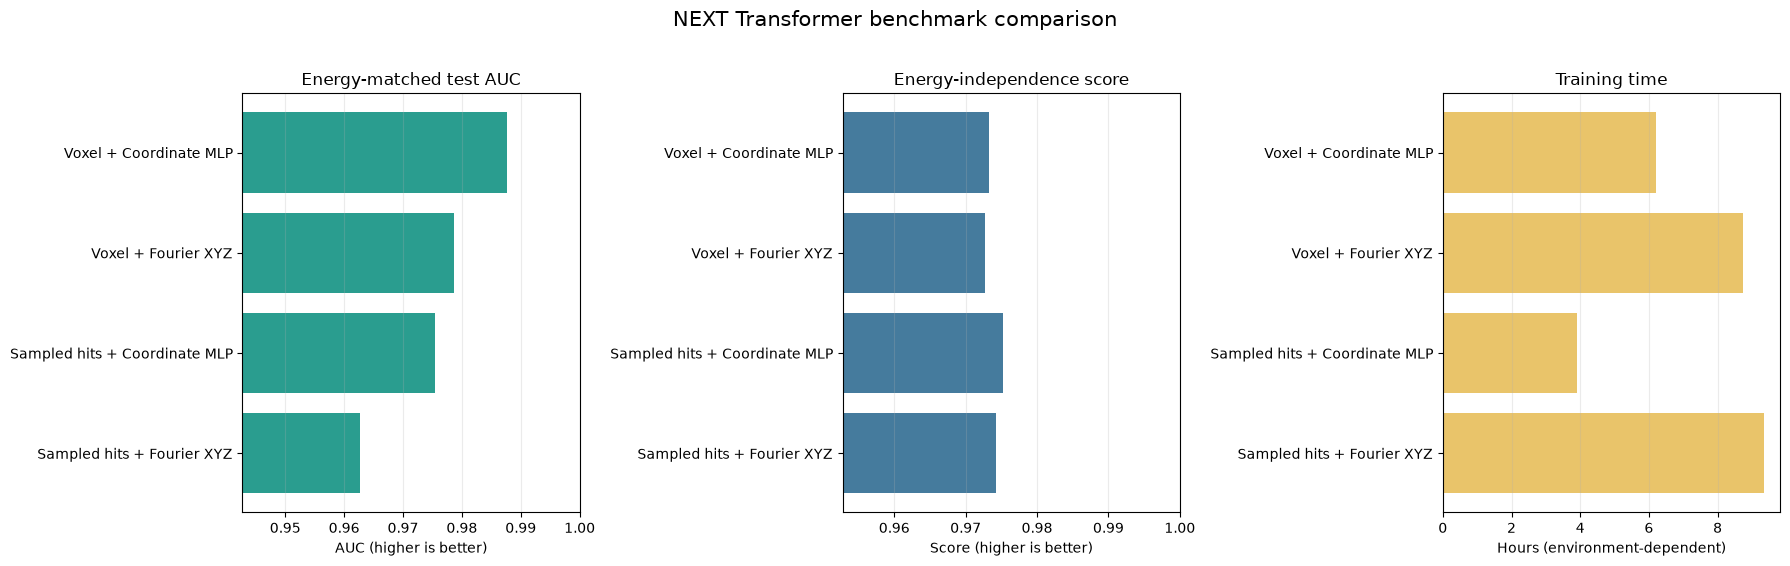

In [5]:
plot_data = ranked.sort_values("energy_matched_auc")
labels = plot_data["model"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

axes[0].barh(labels, plot_data["energy_matched_auc"], color="#2a9d8f")
axes[0].set_title("Energy-matched test AUC")
axes[0].set_xlim(max(0.0, plot_data["energy_matched_auc"].min() - 0.02), 1.0)
axes[0].set_xlabel("AUC (higher is better)")

axes[1].barh(labels, plot_data["energy_independence_score"], color="#457b9d")
axes[1].set_title("Energy-independence score")
axes[1].set_xlim(max(0.0, plot_data["energy_independence_score"].min() - 0.02), 1.0)
axes[1].set_xlabel("Score (higher is better)")

axes[2].barh(labels, plot_data["training_hours"], color="#e9c46a")
axes[2].set_title("Training time")
axes[2].set_xlabel("Hours (environment-dependent)")

for axis in axes:
    axis.grid(axis="x", alpha=0.25)
fig.suptitle("NEXT Transformer benchmark comparison", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

## 5. Saved EnergyBench evaluation figures

These are the figures produced during held-out-test evaluation—not plots recomputed by this reporting notebook.

### Sampled hits + Coordinate MLP

**Inclusive and energy-matched ROC**

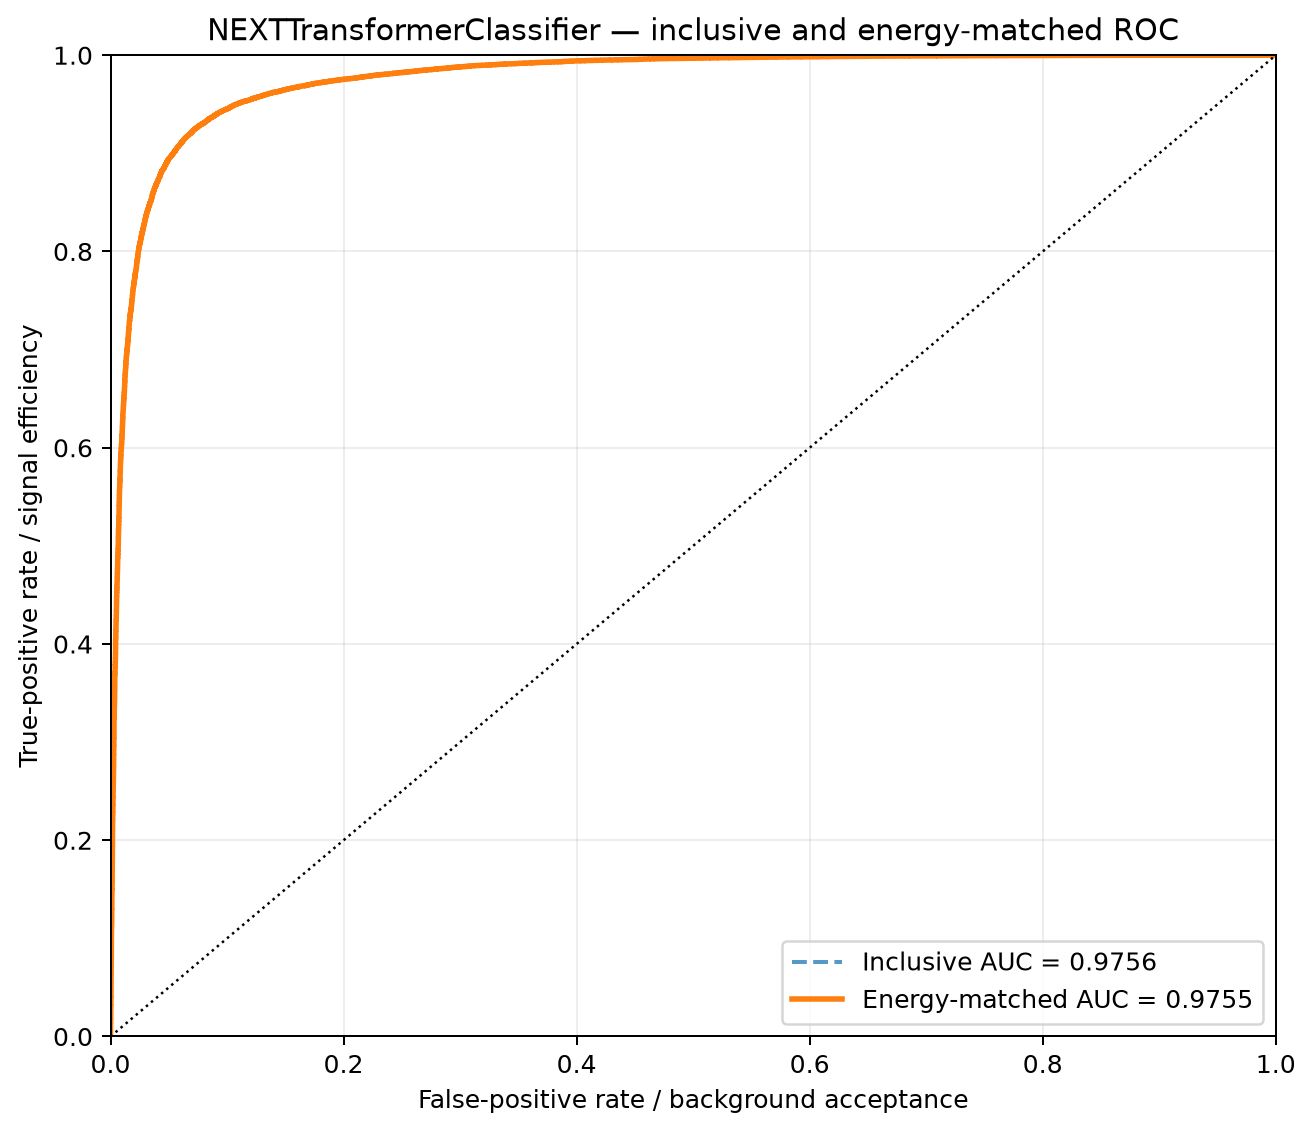

**Score and acceptance versus energy**

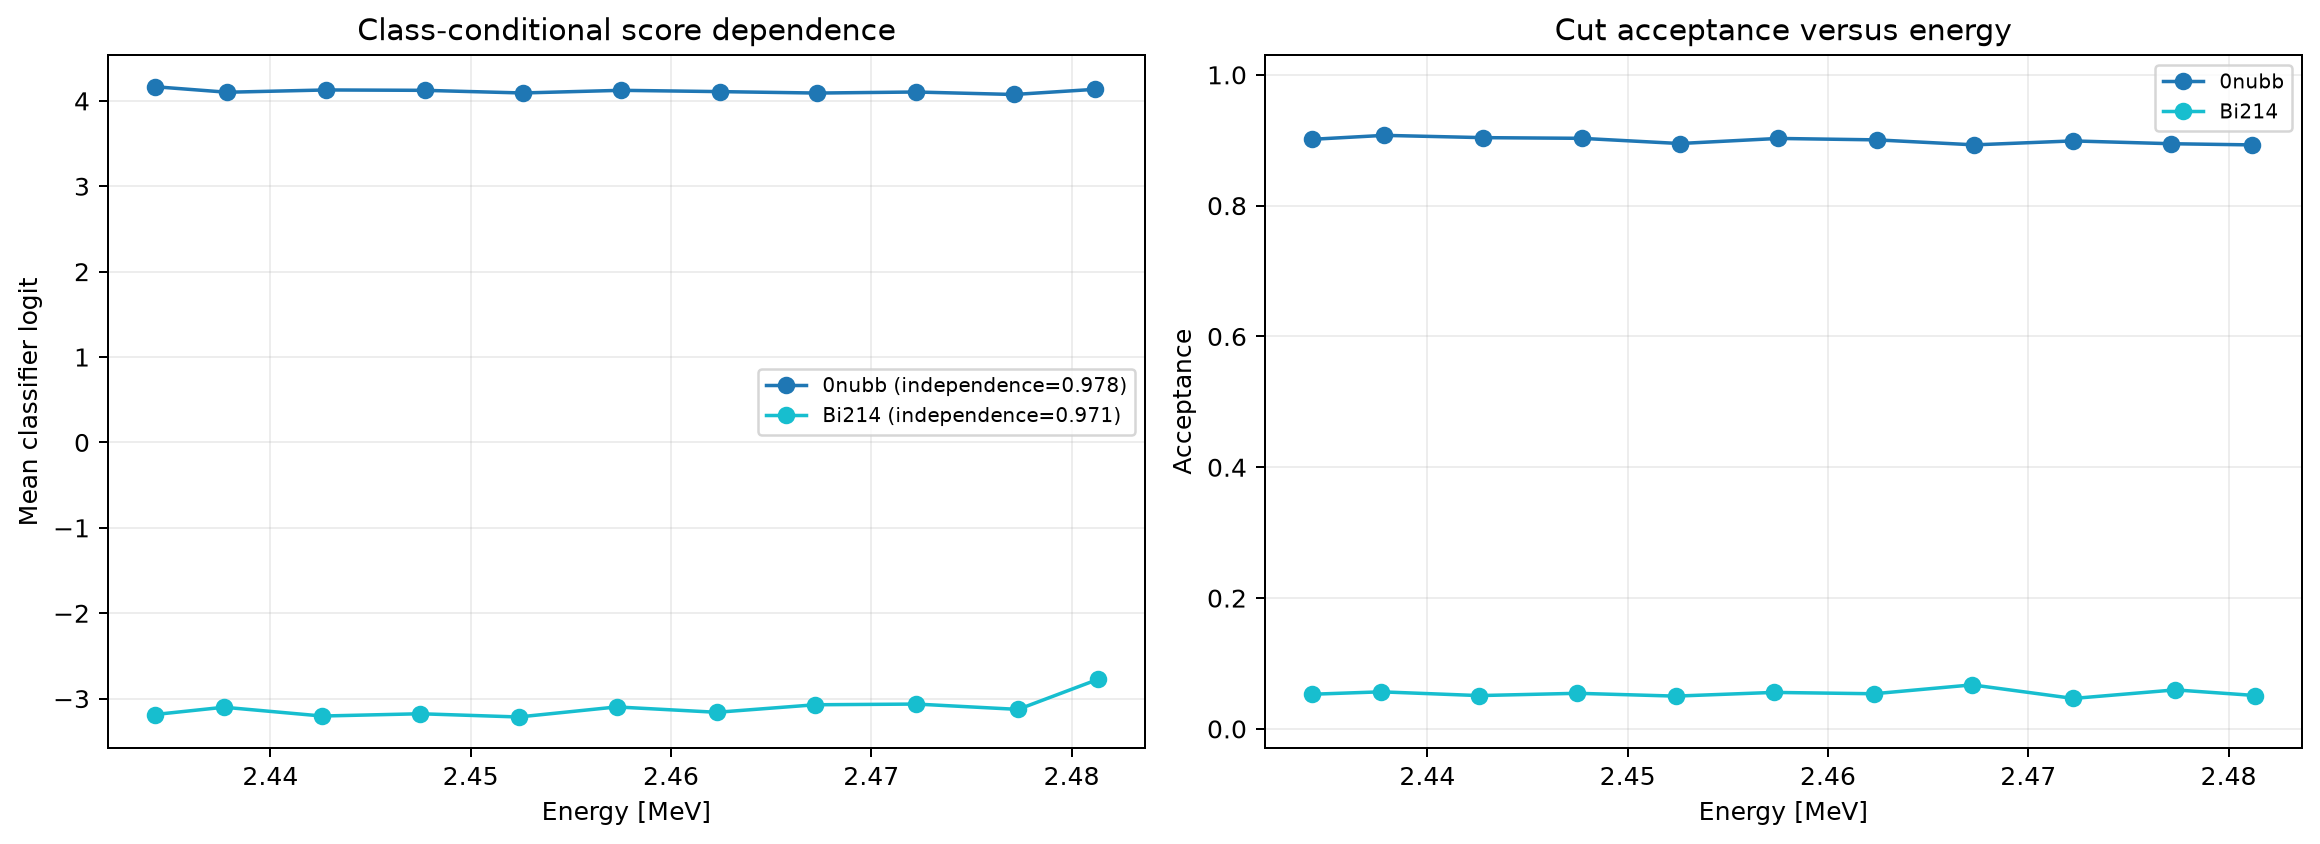

### Voxel + Coordinate MLP

**Inclusive and energy-matched ROC**

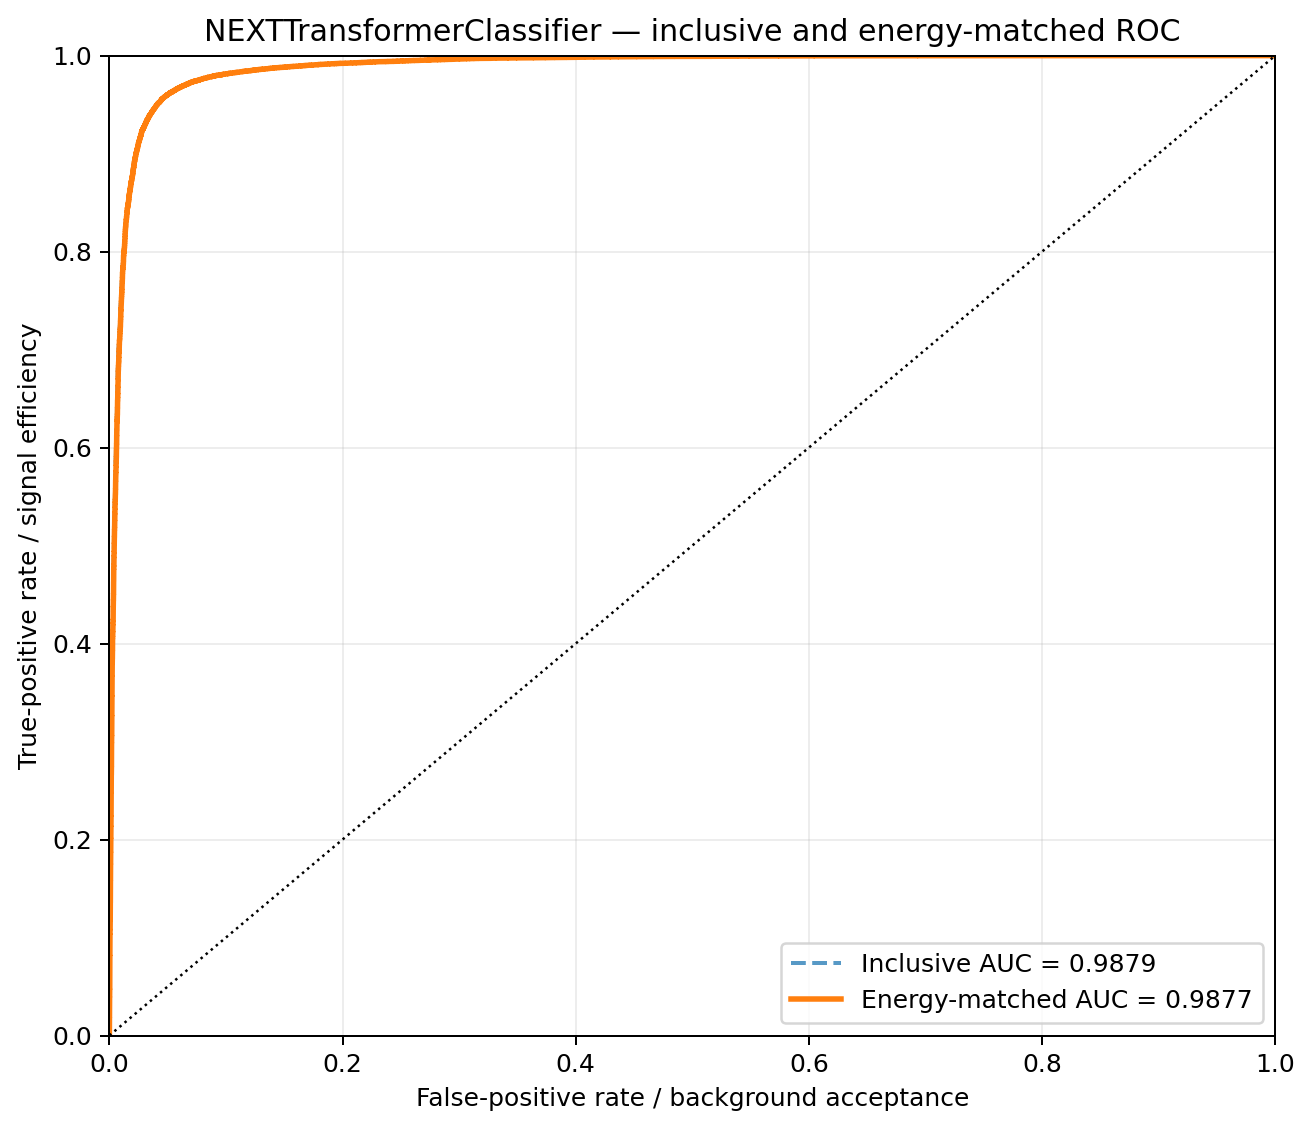

**Score and acceptance versus energy**

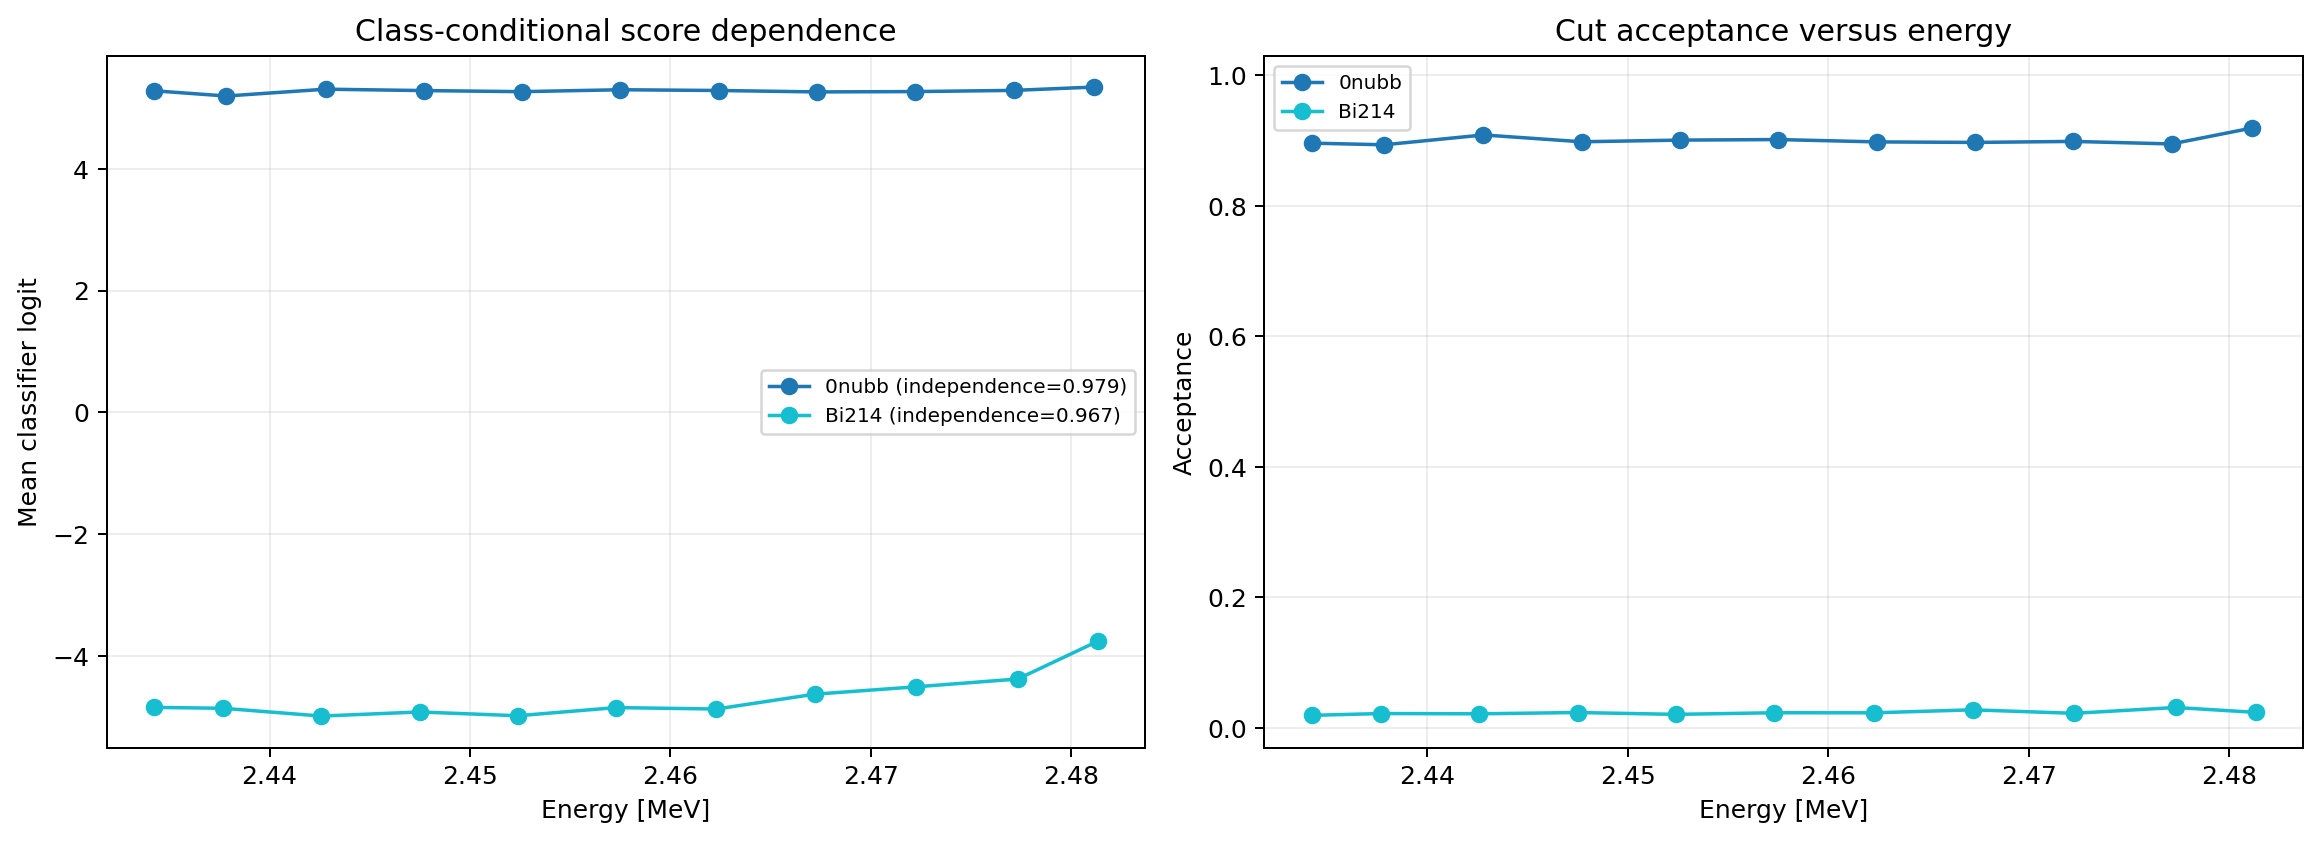

### Voxel + Fourier XYZ

**Inclusive and energy-matched ROC**

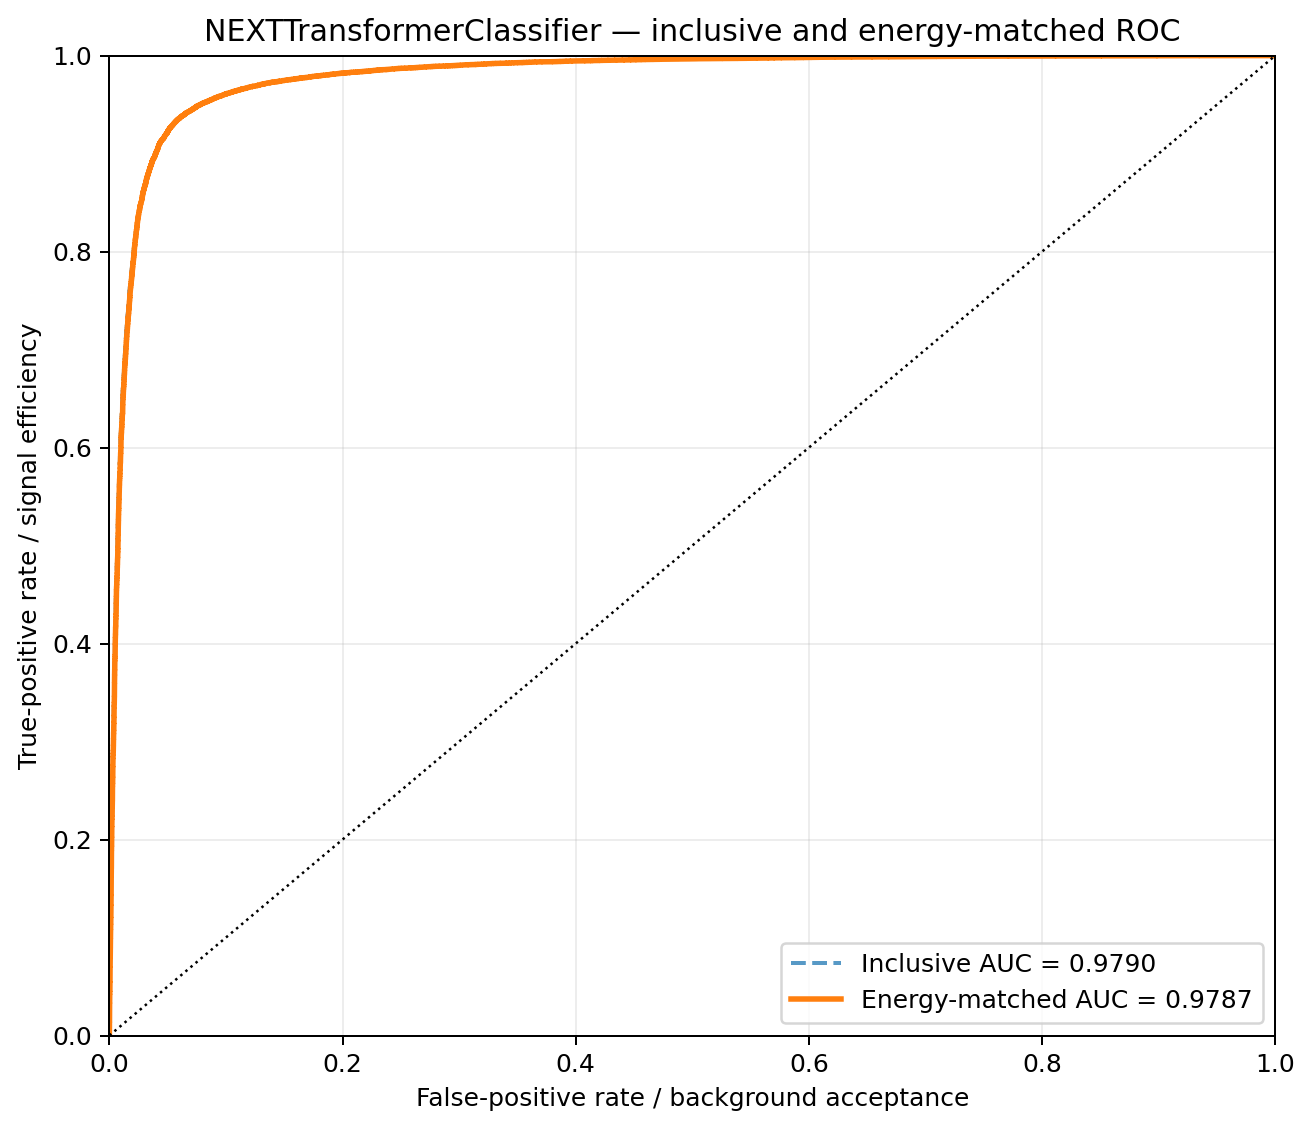

**Score and acceptance versus energy**

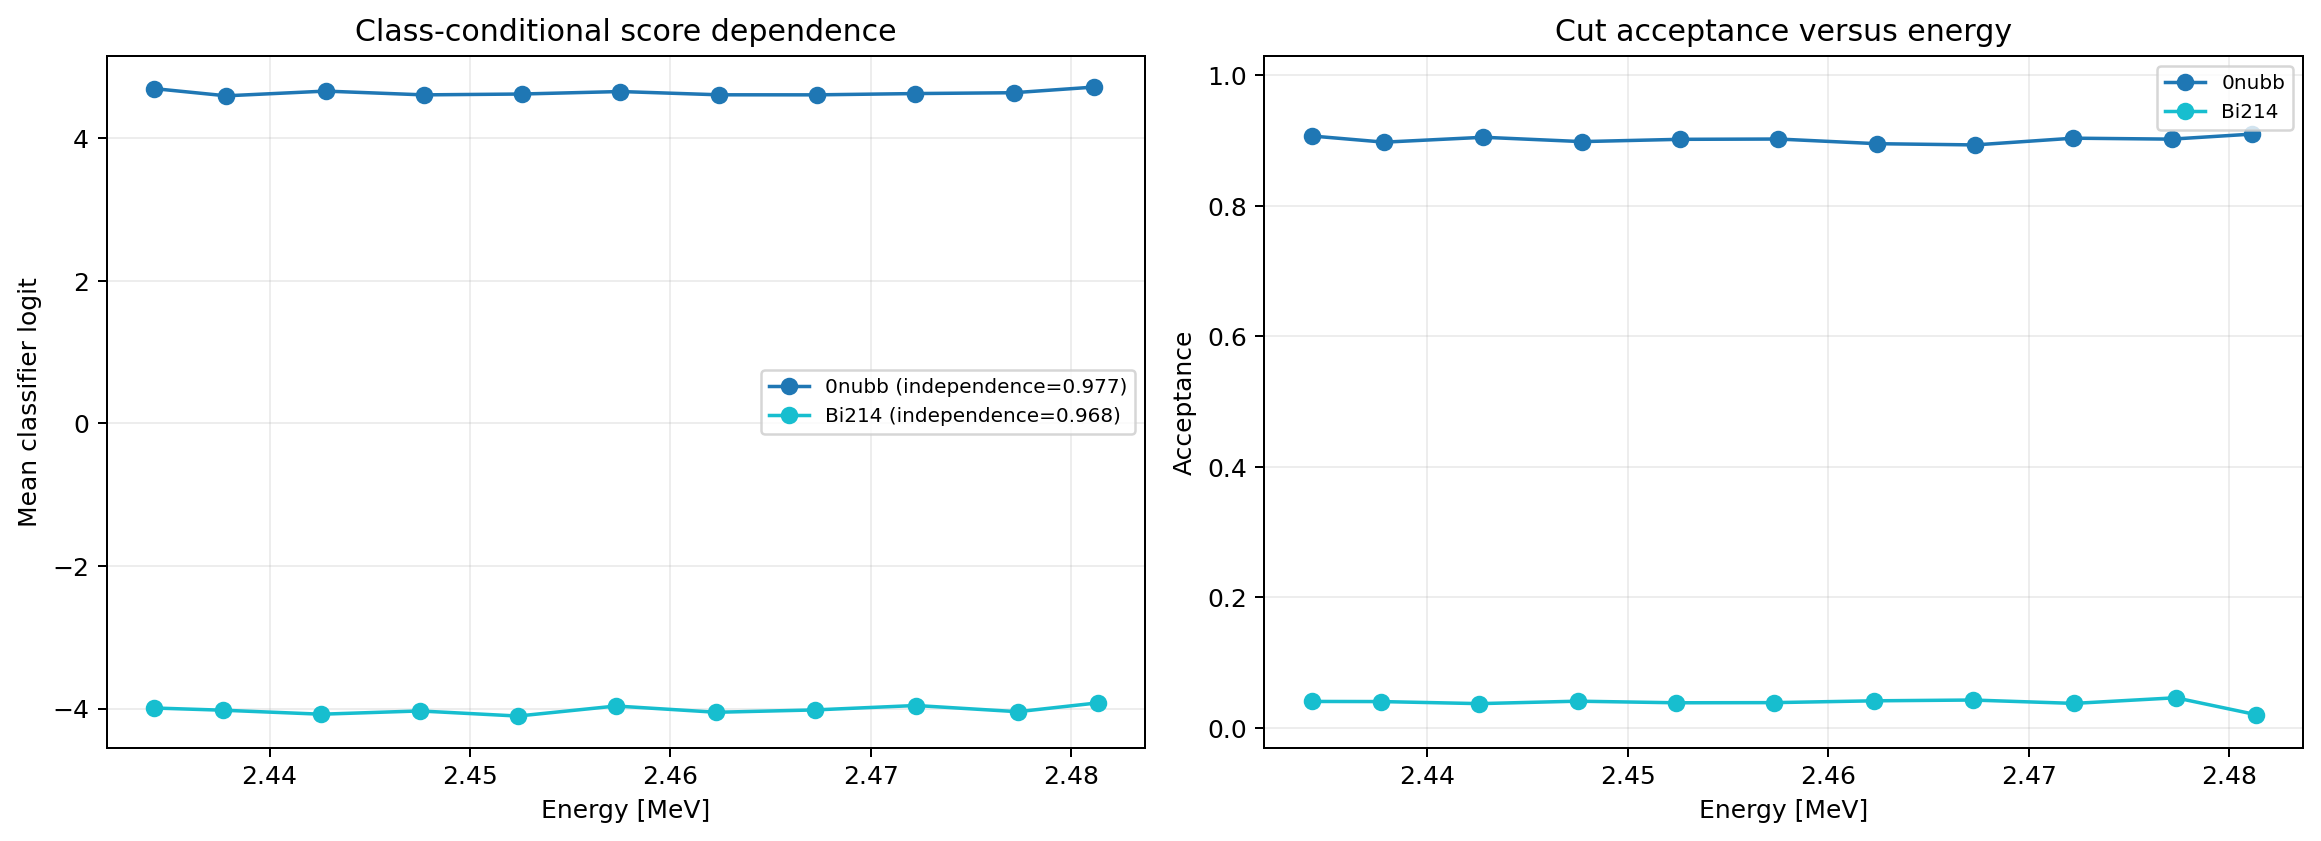

### Sampled hits + Fourier XYZ

**Inclusive and energy-matched ROC**

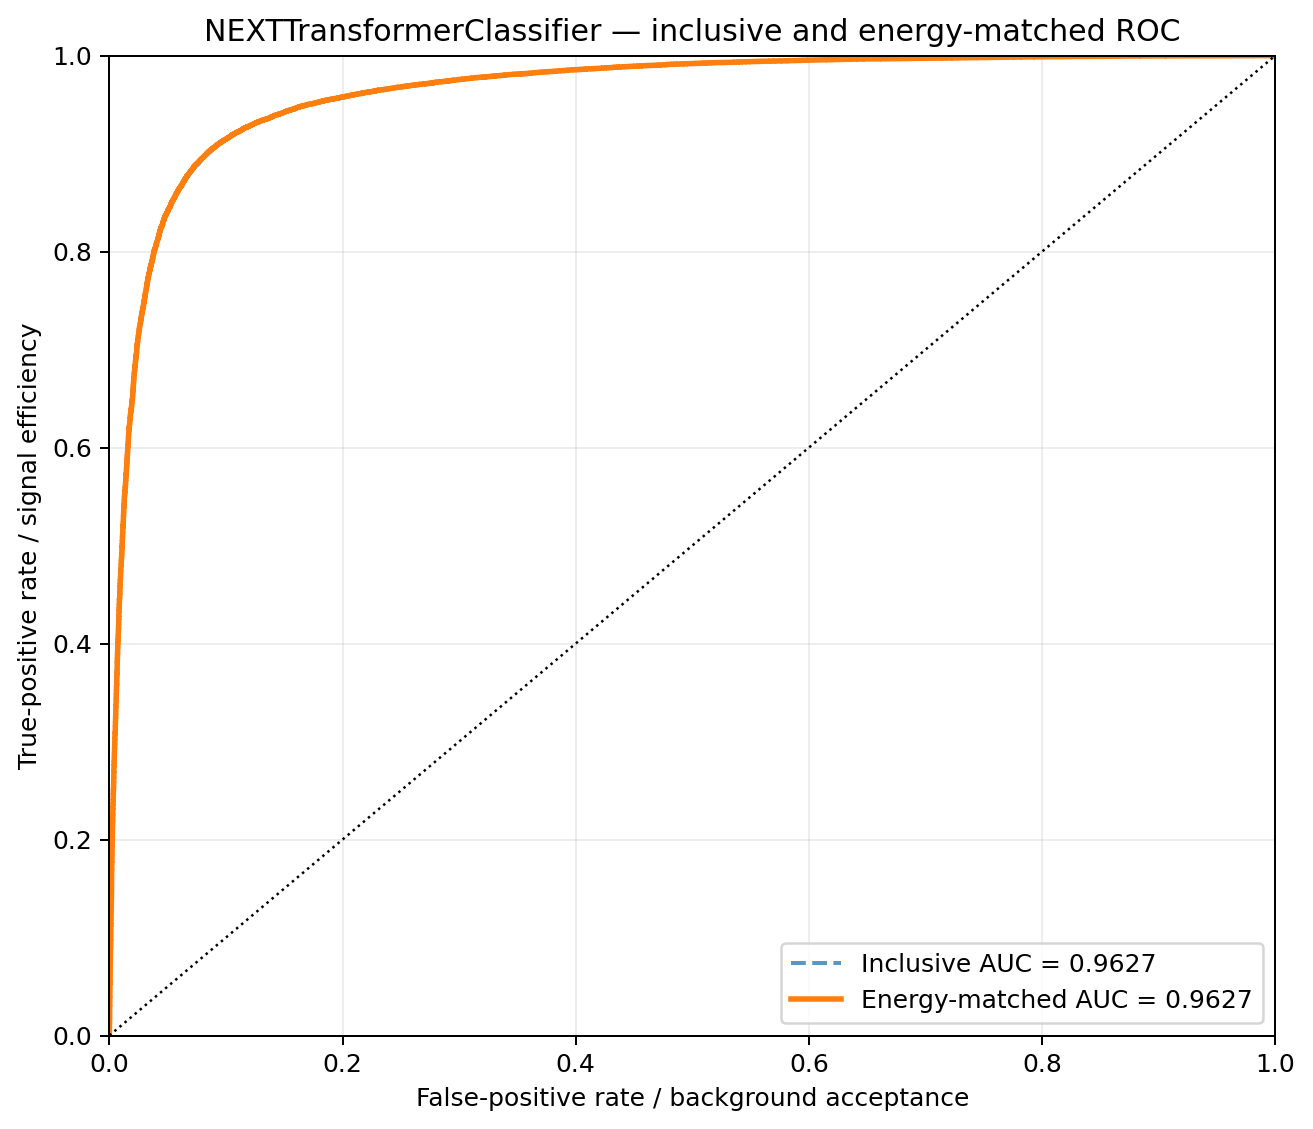

**Score and acceptance versus energy**

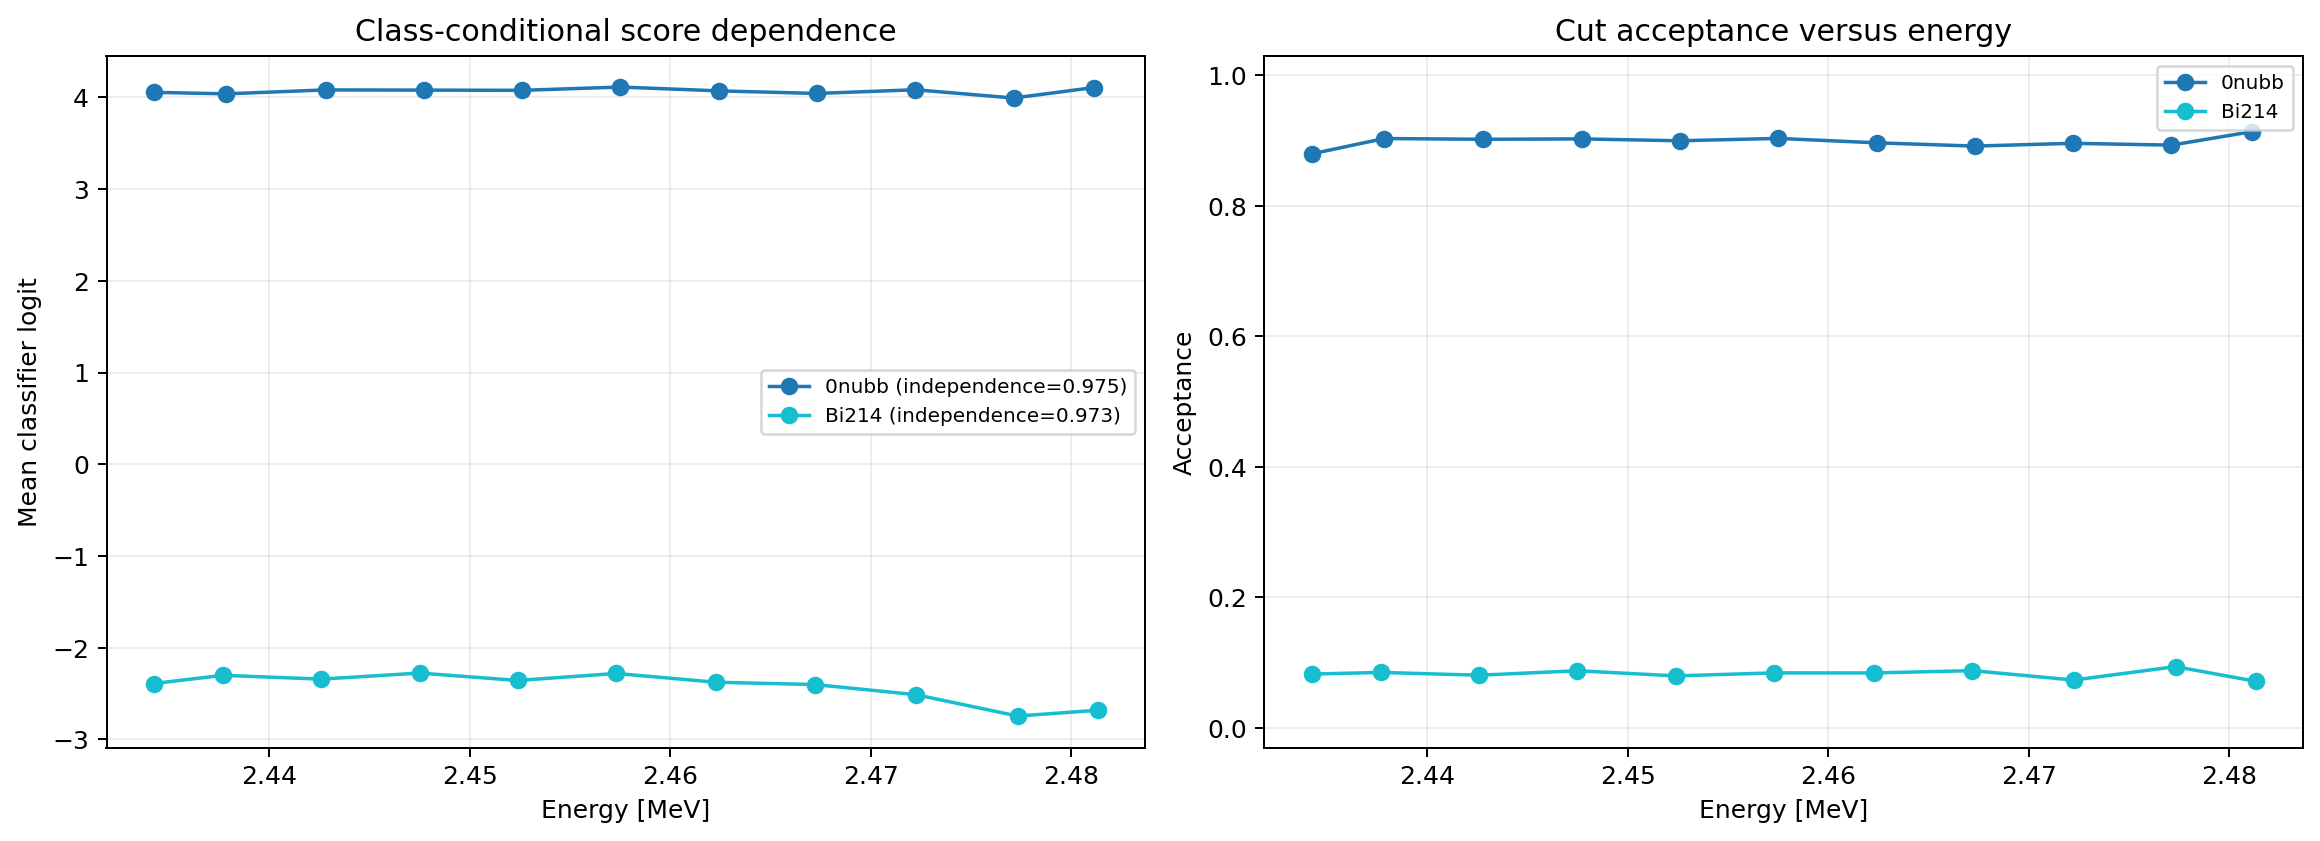

In [6]:
for model_id in EXPECTED_MODELS:
    if model_id not in completed:
        continue
    display(Markdown(f"### {DISPLAY_NAMES[model_id]}"))
    evaluation_root = RESULTS_ROOT / model_id / "evaluation"
    for filename, title in [
        ("energy_matched_roc.png", "Inclusive and energy-matched ROC"),
        ("score_energy_dependence.png", "Score and acceptance versus energy"),
    ]:
        path = evaluation_root / filename
        display(Markdown(f"**{title}**"))
        if path.is_file():
            display(Image(filename=str(path), width=900))
        else:
            display(Markdown(f"⚠️ Missing artifact: `{path}`"))

## 6. Automatically generated takeaway

Use this as a factual starting point for the presentation. Runtime comparisons are descriptive because the lab GPU was shared during these runs.

In [7]:
winner = ranked.iloc[0]
runner_up = ranked.iloc[1] if len(ranked) > 1 else None
takeaway = (
    f"**Best completed model:** {winner['model']}  \n"
    f"**Energy-matched test AUC:** {winner['energy_matched_auc']:.6f}  \n"
    f"**Inclusive test AUC:** {winner['inclusive_auc']:.6f}  \n"
    f"**Energy-independence score:** {winner['energy_independence_score']:.6f}  \n"
    f"**Worst-group energy-independence:** {winner['worst_energy_independence_score']:.6f}  \n"
    f"**Shortcut gap:** {winner['shortcut_gap']:.6f}"
)
if runner_up is not None:
    difference = winner["energy_matched_auc"] - runner_up["energy_matched_auc"]
    takeaway += (
        f"  \n\nIt exceeded the second-ranked model, **{runner_up['model']}**, "
        f"by {difference:.6f} AUC ({100 * difference:.3f} percentage points)."
    )
if missing:
    takeaway += f"  \n\n⚠️ This conclusion is provisional because {len(missing)} expected model(s) are missing."
display(Markdown(takeaway))

**Best completed model:** Voxel + Coordinate MLP  
**Energy-matched test AUC:** 0.987718  
**Inclusive test AUC:** 0.987943  
**Energy-independence score:** 0.973246  
**Worst-group energy-independence:** 0.966642  
**Shortcut gap:** 0.000214  

It exceeded the second-ranked model, **Voxel + Fourier XYZ**, by 0.009021 AUC (0.902 percentage points).